In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# TODO: double check the accuracy of these values
# 1. remove sapphire
# 2. average remaining categories

records = [

    ("MoS2-Sef",  4, "GPR",  22.99, 0.5985),
    ("MoS2-Sef",  4, "RNAN", 39.96, 0.9497),
    ("MoS2-Sef",  4, "Ours", 40.32, 0.9530),

    ("MoS2-Sef", 16, "GPR",  23.20, 0.6990),
    ("MoS2-Sef", 16, "RNAN", 35.51, 0.8803),
    ("MoS2-Sef", 16, "Ours", 35.90, 0.8903),

    ("MoS2-Sef", 64, "Ours", 31.86, 0.8062),

    # ("Sapphire",  4, "GPR",  40.67, 0.9594),
    # ("Sapphire",  4, "RNAN", 48.05, 0.9846),
    # ("Sapphire",  4, "Ours", 48.20, 0.9852),
    # ("Sapphire", 16, "GPR",  39.84, 0.9571),
    # ("Sapphire", 16, "RNAN", 45.81, 0.9775),
    # ("Sapphire", 16, "Ours", 45.97, 0.9782),
    # ("Sapphire", 64, "Ours", 43.77, 0.9711),

    ("Silicon",   4, "GPR",  34.37, 0.9170),
    ("Silicon",   4, "RNAN", 48.11, 0.9847),
    ("Silicon",   4, "Ours", 48.15, 0.9851),

    ("Silicon",  16, "GPR",  38.51, 0.9478),
    ("Silicon",  16, "RNAN", 45.65, 0.9770),
    ("Silicon",  16, "Ours", 45.95, 0.9781),

    ("Silicon",  64, "Ours", 43.87, 0.9715),

]

records = [

    ("", 4, "GPR",  (22.99 + 34.37) / 2, (0.5985 + 0.9170) / 2),
    ("", 4, "RNAN", (39.96 + 48.11) / 2, (0.9497 + 0.9847) / 2),
    ("", 4, "Ours", (40.32 + 48.15) / 2, (0.9530 + 0.9851) / 2),
    
    ("", 16, "GPR", (23.20 + 38.51) / 2, (0.6990 + 0.9478) / 2),
    ("", 16, "RNAN",(35.51 + 45.65) / 2, (0.8803 + 0.9770) / 2),
    ("", 16, "Ours",(35.90 + 45.95) / 2, (0.8903 + 0.9781) / 2),

    ("", 64, "Ours",(31.86 + 43.87) / 2, (0.8062 + 0.9715) / 2),

]

In [15]:
df = pd.DataFrame(records, columns=["Dataset", "Ratio", "Method", "PSNR", "SSIM"])
df["Category"] = df["Dataset"] + r" ×" + df["Ratio"].astype(str)
categories = list(dict.fromkeys(df["Category"]))  # preserve order

/home/mufan/miniforge3/envs/torp/lib/python3.10/site-packages/numpy/lib/_stride_tricks_impl.py:542: UserWarning: Warning: converting a masked element to nan.
  args = [np.array(_m, copy=None, subok=subok) for _m in args]
/home/mufan/miniforge3/envs/torp/lib/python3.10/site-packages/numpy/lib/_stride_tricks_impl.py:542: UserWarning: Warning: converting a masked element to nan.
  args = [np.array(_m, copy=None, subok=subok) for _m in args]


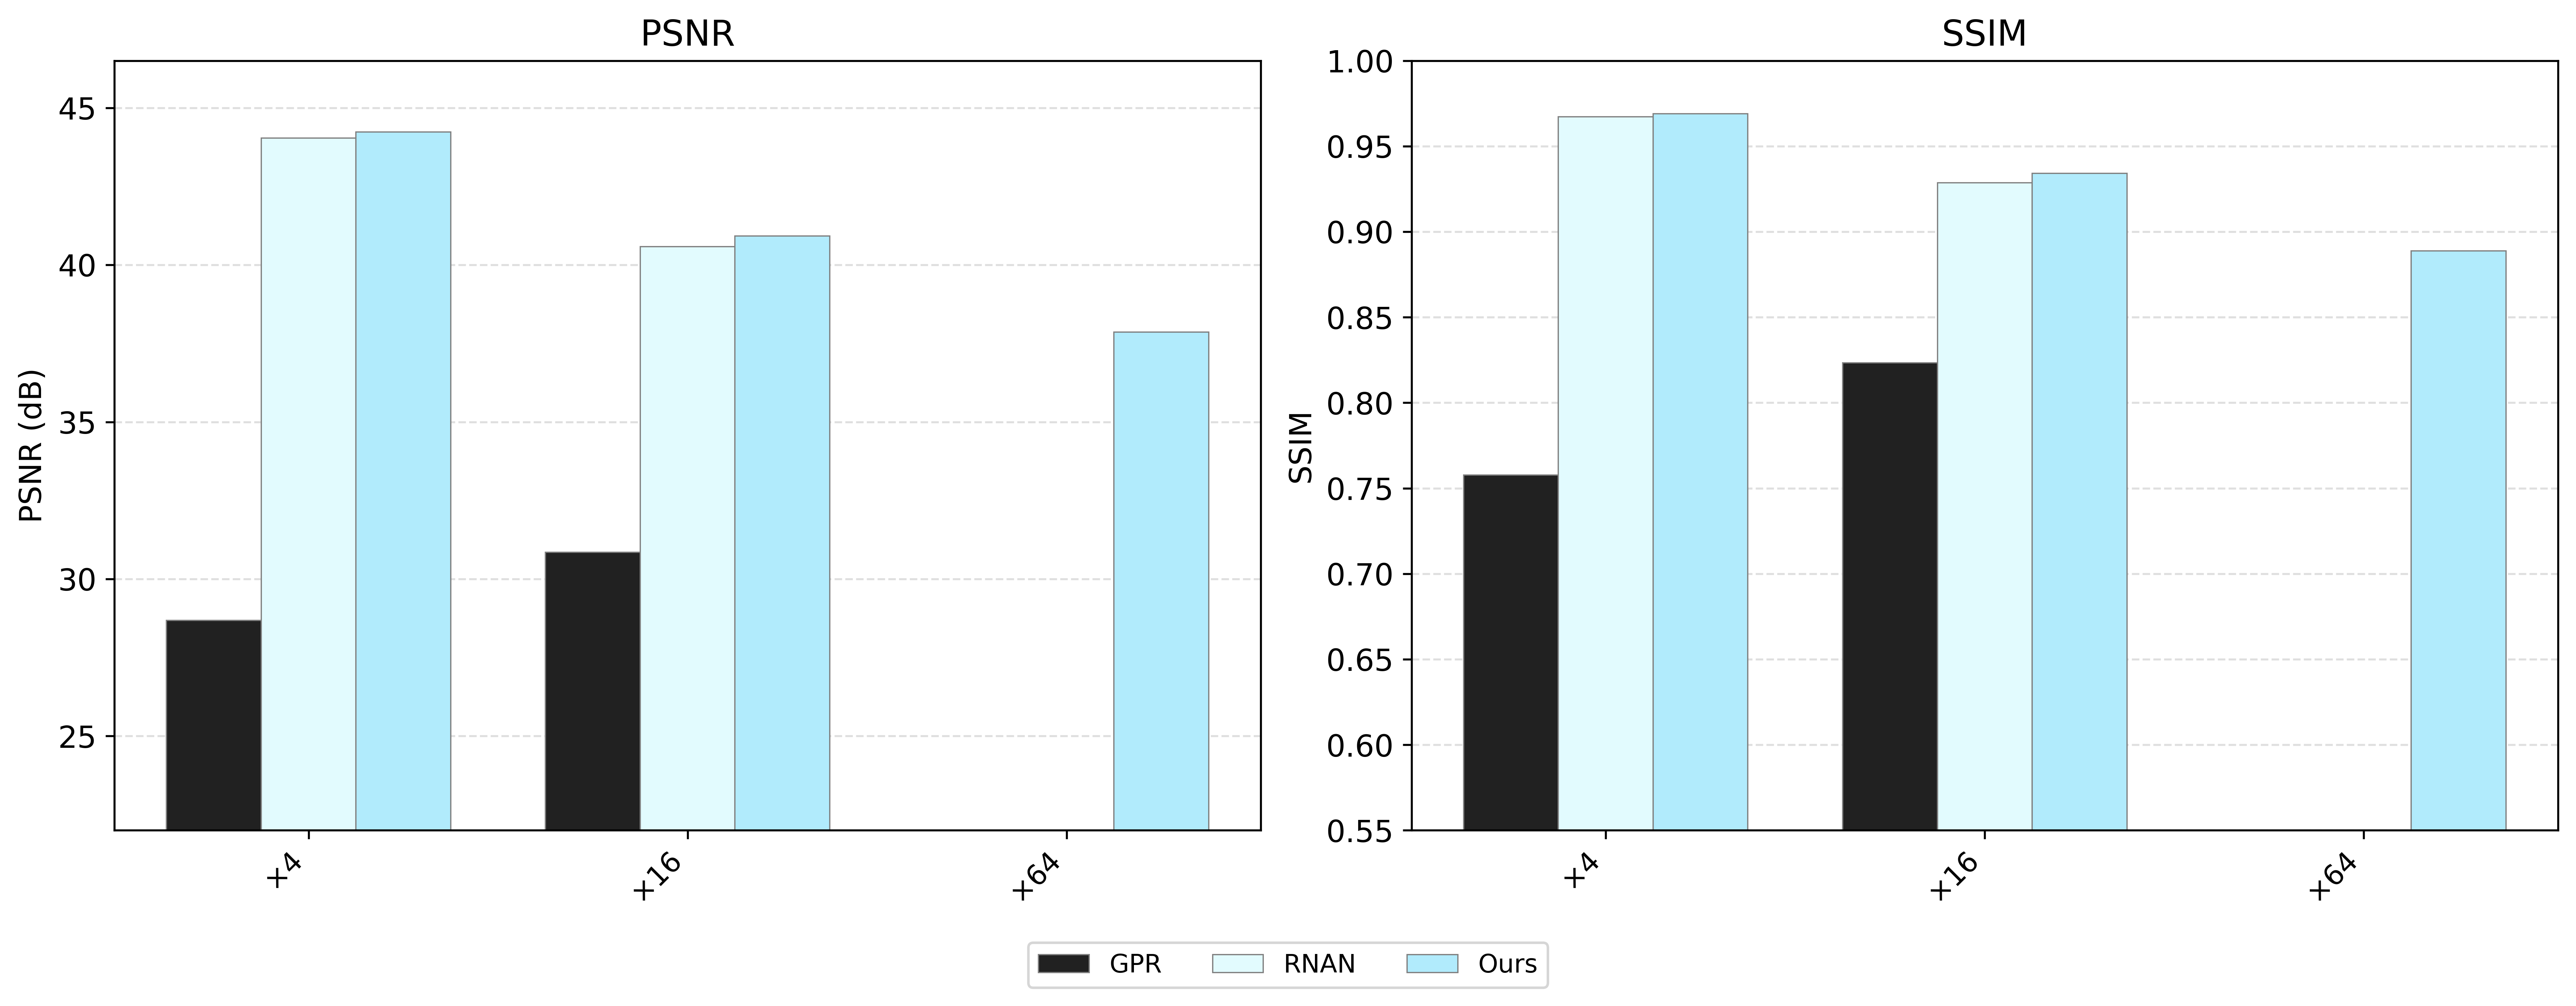

In [18]:

methods   = ["GPR", "RNAN", "Ours"]
bar_width = 0.25
x         = np.arange(len(categories))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True, dpi=600)

# custom color palette
color_palette = {
    "GPR":  "#212121",
    "RNAN": "#e2fbfe",
    "Ours": "#b1ebfc"
}
# fig.set_facecolor("#f0f0f0")

for ax, metric in zip(axes, ["PSNR", "SSIM"]):
    
    # set a white background for the plot area
    ax.set_facecolor("white")
    
    # add a subtle background grid
    ax.grid(True, axis="y", alpha=0.4, linestyle='--')
    ax.set_axisbelow(True)

    for m_idx, method in enumerate(methods):
        subset = df[df["Method"] == method]
        vals = [
            subset.loc[subset["Category"] == cat, metric].values[0]
            if not subset.loc[subset["Category"] == cat, metric].empty else np.nan
            for cat in categories
        ]
        
        ax.bar(x + (m_idx - 1) * bar_width,
               np.ma.array(vals, mask=np.isnan(vals)),
               bar_width,
               label=method,
               color=color_palette[method],
               edgecolor='grey',
               linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel(metric + (" (dB)" if metric == "PSNR" else ""), fontsize=12)
    ax.set_title(metric, fontsize=14)
    
    ax.tick_params(axis='y', labelsize=12)

axes[0].set_ylim(bottom=22, top=46.5)
axes[1].set_ylim(bottom=0.55, top=1.0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(methods),
           loc="lower center", bbox_to_anchor=(0.5, -0.085))

fig.savefig("recon_histograms_combined.png", dpi=1200, bbox_inches="tight")
plt.show()